# 🐾 PetFinder – Meta-Modelo: ResNet50 + Random Forest (Soft Voting)

**Arquitectura:**
```
Imágenes  →  ResNet50  →  proba_imagen  (5 clases)
                                            ↓
Tabular   →  RandomForest  →  proba_tab  →  Promedio  →  Predicción Final
```

**Métrica principal:** Quadratic Weighted Kappa (QWK)

## 0. Configuración de rutas y parámetros

In [1]:
import os

# ============================================================
# BASE
# ============================================================
BASE_PATH = r"C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental"

# ============================================================
# RUTAS CORRECTAS 🔥
# ============================================================
PATH_TO_TRAIN_CSV  = os.path.join(BASE_PATH, "train", "train.csv")
PATH_TO_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")

# Carpeta de trabajo (se crea sola)
PATH_TO_WORK = os.path.join(BASE_PATH, "petfinder_work")

# ============================================================
# HIPERPARÁMETROS
# ============================================================
SEED        = 42
TEST_SIZE   = 0.2
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
LR          = 0.001
MOMENTUM    = 0.9
NUM_CLASSES = 5
CPU_CORES   = min(os.cpu_count(), 4)

# ============================================================
# CREAR WORK DIR
# ============================================================
os.makedirs(PATH_TO_WORK, exist_ok=True)

# ============================================================
# DEBUG (MUY IMPORTANTE)
# ============================================================
print("CSV existe:", os.path.exists(PATH_TO_TRAIN_CSV))
print("Images dir existe:", os.path.exists(PATH_TO_IMAGES_DIR))

print(f"\nCarpeta de trabajo: {PATH_TO_WORK}")

CSV existe: True
Images dir existe: True

Carpeta de trabajo: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\petfinder_work


## 1. Imports

In [7]:
import numpy as np
import pandas as pd
import shutil
import copy
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score
)
from joblib import dump, load

import torch # type: ignore
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# Reproducibilidad
import random
import torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

ModuleNotFoundError: No module named 'torch'

## 2. Carga y Split de Datos

> **Split único** compartido entre ambos modelos para alinear predicciones correctamente.

In [ ]:
#LEE EL ARCHIVO QUE ESTÁ EN PATH_TO_TRAIN_CSV   = r"C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\train.csv"
df = pd.read_csv(PATH_TO_TRAIN_CSV)


In [ ]:
# =========================
# LOAD
# =========================
df_full = pd.read_csv(PATH_TO_TRAIN_CSV)

print(f"Dataset completo: {df_full.shape}")

# =========================
# TARGET CHECK
# =========================
target_dist = df_full['AdoptionSpeed'].value_counts(normalize=True).sort_index()

print("\nDistribución (%):")
print(target_dist)

# =========================
# SPLIT ESTRATIFICADO
# =========================
train_df, val_df = train_test_split(
    df_full,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df_full['AdoptionSpeed']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | Validación: {len(val_df)}")

# =========================
# VALIDACIÓN DEL SPLIT
# =========================
print("\nDistribución en TRAIN:")
print(train_df['AdoptionSpeed'].value_counts(normalize=True).sort_index())

print("\nDistribución en VAL:")
print(val_df['AdoptionSpeed'].value_counts(normalize=True).sort_index())

Dataset completo: (14993, 24)

Distribución (%):
AdoptionSpeed
0    0.027346
1    0.206096
2    0.269259
3    0.217368
4    0.279931
Name: proportion, dtype: float64

Train: 11994 | Validación: 2999

Distribución en TRAIN:
AdoptionSpeed
0    0.027347
1    0.206103
2    0.269301
3    0.217359
4    0.279890
Name: proportion, dtype: float64

Distribución en VAL:
AdoptionSpeed
0    0.027342
1    0.206069
2    0.269090
3    0.217406
4    0.280093
Name: proportion, dtype: float64


## 3. Modelo 1 – Random Forest (Datos Tabulares)

### 3.1 Feature Engineering

In [ ]:
def feature_engineering(df):
    """Aplica feature engineering al dataframe."""
    df = df.copy()

    # --- Features de descripción ---
    df['Is_Described']      = df['Description'].notnull().astype(int)
    df['Desc_Length']       = df['Description'].fillna('').apply(len)

    # --- Salud ---
    df['Total_Health_Score'] = (
        (df['Vaccinated']  >= 2).astype(int) +
        (df['Dewormed']    >= 2).astype(int) +
        (df['Sterilized']  >= 2).astype(int)
    )
    df['Healthy']       = (df['Total_Health_Score'] >= 3).astype(int)
    df['Premium_Pet']   = (
        (df['Vaccinated'] >= 2) &
        (df['Dewormed']   >= 2) &
        (df['Sterilized'] >= 2)
    ).astype(int)

    # --- Colores ---
    df['Total_Colors']  = (df[['Color1','Color2','Color3']] != 0).sum(axis=1)
    df['Multicolor']    = (df['Total_Colors'] >= 2).astype(int)

    # --- Raza ---
    df['Mixed_Breed']   = (
        (df['Breed1'] != 0) & (df['Breed2'] != 0)
    ).astype(int)

    # --- Calidad del listing ---
    df['High_Quality_Listing'] = (
        (df['PhotoAmt'] >= df['PhotoAmt'].quantile(0.75)) &
        (df['Is_Described'] == 1)
    ).astype(int)

    # --- Precio y edad ---
    df['Affordable']    = (df['Fee']  <= df['Fee'].median()).astype(int)
    df['Young_Pet']     = (df['Age']  <= df['Age'].median()).astype(int)
    df['Age_Fee_Ratio'] = df['Age'] / (df['Fee'] + 1)

    return df


def prepare_tabular(df, fit_columns=None):
    """Prepara X e y para el Random Forest."""
    df = feature_engineering(df)

    cols_to_drop = ['AdoptionSpeed', 'Name', 'RescuerID', 'Description', 'PetID']
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df['AdoptionSpeed']

    X = X.fillna(-999)
    X = pd.get_dummies(X, drop_first=True)

    # Alinear columnas con las del train (para validación)
    if fit_columns is not None:
        X = X.reindex(columns=fit_columns, fill_value=0)

    return X, y


X_train_tab, y_train_tab = prepare_tabular(train_df)
X_val_tab,   y_val_tab   = prepare_tabular(val_df, fit_columns=X_train_tab.columns)

print(f"Features tabulares: {X_train_tab.shape[1]}")
print(f"Train tabular: {X_train_tab.shape} | Val tabular: {X_val_tab.shape}")

Features tabulares: 31
Train tabular: (11994, 31) | Val tabular: (2999, 31)


### 3.2 Entrenamiento del Random Forest

In [ ]:
print("Entrenando Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_tab, y_train_tab)

# Predicciones sobre validación
rf_preds_class = rf_model.predict(X_val_tab)
rf_preds_proba = rf_model.predict_proba(X_val_tab)   # shape: (N_val, 5)

rf_qwk = cohen_kappa_score(y_val_tab, rf_preds_class, weights='quadratic')
rf_acc = (rf_preds_class == y_val_tab.values).mean()

print(f"\n✅ Random Forest → Accuracy: {rf_acc:.4f} | QWK: {rf_qwk:.4f}")

# Guardar modelo
rf_path = os.path.join(PATH_TO_WORK, 'random_forest.joblib')
dump(rf_model, rf_path)
print(f"Modelo guardado: {rf_path}")

Entrenando Random Forest...

✅ Random Forest → Accuracy: 0.4105 | QWK: 0.3400
Modelo guardado: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\petfinder_work\random_forest.joblib


### 3.3 Importancia de Variables (Top 15)

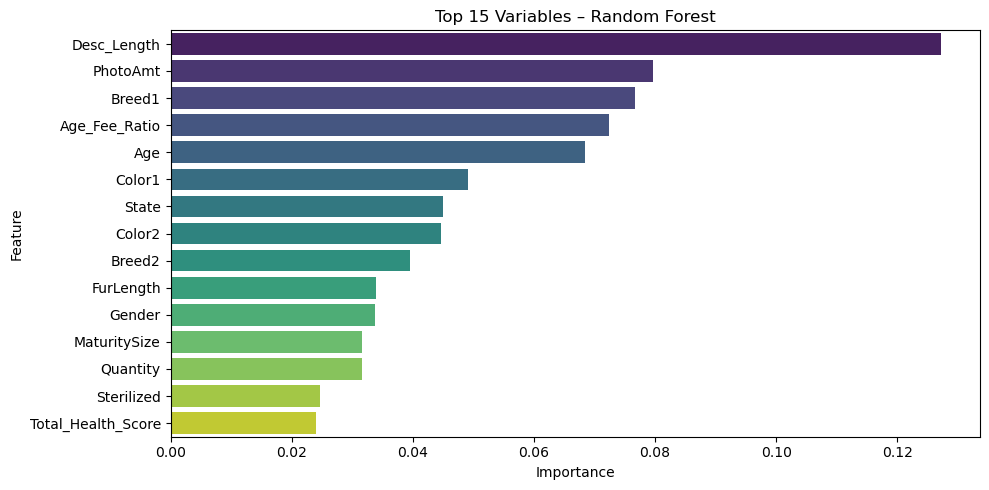

In [ ]:
feat_imp = pd.DataFrame({
    'Feature':    X_train_tab.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variables – Random Forest')
plt.tight_layout()
plt.show()

## 4. Modelo 2 – ResNet50 (Imágenes)

### 4.1 Preparar directorios de imágenes para PyTorch ImageFolder

In [ ]:
# PyTorch ImageFolder espera: directorio/clase/imagen.jpg
TRAIN_IMG_DIR = os.path.join(PATH_TO_WORK, 'train_images_classes')
VAL_IMG_DIR   = os.path.join(PATH_TO_WORK, 'val_images_classes')
CLASS_NAMES   = ['0', '1', '2', '3', '4']

# Crear carpetas de clases
for split_dir in [TRAIN_IMG_DIR, VAL_IMG_DIR]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)


def copy_images(df, dest_dir, images_dir):
    """Copia imágenes al directorio de clases de PyTorch."""
    missing, copied = 0, 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Copiando a {os.path.basename(dest_dir)}'):
        pet_id = row['PetID']
        label  = str(row['AdoptionSpeed'])
        src    = os.path.join(images_dir, f'{pet_id}-1.jpg')
        dst    = os.path.join(dest_dir, label, f'{pet_id}-1.jpg')
        if os.path.exists(src):
            if not os.path.exists(dst):          # evitar copiar dos veces
                shutil.copy2(src, dst)
            copied += 1
        else:
            missing += 1
    print(f"  Copiadas: {copied} | Sin imagen: {missing}")


# Solo copiar si los directorios están vacíos
train_has_images = any(
    os.listdir(os.path.join(TRAIN_IMG_DIR, c))
    for c in CLASS_NAMES
    if os.path.exists(os.path.join(TRAIN_IMG_DIR, c))
)

if not train_has_images:
    copy_images(train_df, TRAIN_IMG_DIR, PATH_TO_IMAGES_DIR)
    copy_images(val_df,   VAL_IMG_DIR,   PATH_TO_IMAGES_DIR)
else:
    print("Las imágenes ya están copiadas. Saltando este paso.")

Copiando a train_images_classes: 100%|██████████| 11994/11994 [01:49<00:00, 110.01it/s]


  Copiadas: 11721 | Sin imagen: 273


Copiando a val_images_classes: 100%|██████████| 2999/2999 [00:08<00:00, 368.56it/s]

  Copiadas: 2931 | Sin imagen: 68


### 4.2 DataLoaders con Data Augmentation estándar

In [ ]:
# Estadísticas de normalización de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = datasets.ImageFolder(TRAIN_IMG_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_IMG_DIR,   transform=val_transforms)

# Asignar clases en orden correcto (0→4)
class_to_idx = {c: int(c) for c in CLASS_NAMES}
train_dataset.class_to_idx = class_to_idx
val_dataset.class_to_idx   = class_to_idx

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=CPU_CORES, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=CPU_CORES, pin_memory=True)

# PetIDs en el orden exacto del val_loader (para alinear con RF)
val_pet_ids = [
    os.path.basename(path).split('-')[0]
    for path, _ in val_dataset.samples
]

print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)}")
print(f"Clases detectadas: {train_dataset.class_to_idx}")

Train images: 11721 | Val images: 2931
Clases detectadas: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


### 4.3 Definición del Modelo ResNet50

In [ ]:
def build_resnet50(num_classes=5, freeze_backbone=False):
    """
    ResNet50 preentrenado en ImageNet.
    Se reemplaza la última capa FC por una de `num_classes` salidas.
    Opcionalmente se congela el backbone para un warm-up rápido.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Reemplazar la capa final
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model.to(DEVICE)


resnet50 = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=False)
criterion = nn.CrossEntropyLoss()

total_params     = sum(p.numel() for p in resnet50.parameters())
trainable_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales:     23,518,277
Parámetros entrenables: 23,518,277


### 4.4 Loop de Entrenamiento ResNet50

In [ ]:
def train_resnet(
    model, criterion, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR, momentum=MOMENTUM
):
    """
    Entrena el modelo y devuelve:
        - best_model: pesos con mejor QWK en validación
        - val_proba:  probabilidades (softmax) en validación, shape (N_val, 5)
        - val_labels: etiquetas verdaderas del val set
        - history:    dict con listas de loss/acc/kappa por epoch
    """
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_kappa     = -999.0
    best_val_proba = None
    best_val_labels = None

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_kappa': []}
    since   = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}  (lr={scheduler.get_last_lr()[0]:.6f})")
        print('-' * 50)

        # ── TRAIN ──────────────────────────────────────────
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc='  Train', leave=False):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # ── VALIDATION ─────────────────────────────────────
        model.eval()
        running_loss    = 0.0
        all_labels      = []
        all_preds       = []
        all_proba       = []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='  Val  ', leave=False):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)

                proba  = torch.softmax(outputs, dim=1).cpu().numpy()
                preds  = np.argmax(proba, axis=1)

                all_labels.extend(labels.cpu().numpy().tolist())
                all_preds.extend(preds.tolist())
                all_proba.extend(proba.tolist())

        epoch_val_loss  = running_loss / len(val_loader.dataset)
        epoch_val_acc   = np.mean(np.array(all_preds) == np.array(all_labels))
        epoch_val_kappa = cohen_kappa_score(
            all_labels, all_preds, weights='quadratic'
        )

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['val_kappa'].append(epoch_val_kappa)

        print(f"  Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc*100:.2f}% | "
              f"Val QWK: {epoch_val_kappa:.4f}")

        scheduler.step()

        if epoch_val_kappa > best_kappa:
            best_kappa      = epoch_val_kappa
            best_model_wts  = copy.deepcopy(model.state_dict())
            best_val_proba  = np.array(all_proba)
            best_val_labels = np.array(all_labels)
            print(f"  ⭐ Mejor QWK hasta ahora: {best_kappa:.4f} – modelo guardado")

    elapsed = time.time() - since
    print(f"\nEntrenamiento completo en {elapsed//60:.0f}m {elapsed%60:.0f}s")
    print(f"Mejor QWK en validación: {best_kappa:.4f}")

    model.load_state_dict(best_model_wts)
    return model, best_val_proba, best_val_labels, history


resnet50, resnet_val_proba, resnet_val_labels, history = train_resnet(
    resnet50, criterion, train_loader, val_loader
)

# Guardar modelo
resnet_path = os.path.join(PATH_TO_WORK, 'resnet50_best.pth')
torch.save(resnet50.state_dict(), resnet_path)
print(f"\nModelo guardado: {resnet_path}")


Epoch 1/5  (lr=0.001000)
--------------------------------------------------


  Train Loss: 1.4470 | Val Loss: 1.4084 | Val Acc: 34.25% | Val QWK: 0.2455
  ⭐ Mejor QWK hasta ahora: 0.2455 – modelo guardado

Epoch 2/5  (lr=0.000905)
--------------------------------------------------


  Train Loss: 1.4034 | Val Loss: 1.4080 | Val Acc: 33.54% | Val QWK: 0.2751
  ⭐ Mejor QWK hasta ahora: 0.2751 – modelo guardado

Epoch 3/5  (lr=0.000655)
--------------------------------------------------


  Train Loss: 1.3878 | Val Loss: 1.4075 | Val Acc: 34.36% | Val QWK: 0.2783
  ⭐ Mejor QWK hasta ahora: 0.2783 – modelo guardado

Epoch 4/5  (lr=0.000345)
--------------------------------------------------


  Train Loss: 1.3742 | Val Loss: 1.4040 | Val Acc: 34.25% | Val QWK: 0.2779

Epoch 5/5  (lr=0.000095)
--------------------------------------------------


  Train Loss: 1.3663 | Val Loss: 1.4025 | Val Acc: 34.73% | Val QWK: 0.2909
  ⭐ Mejor QWK hasta ahora: 0.2909 – modelo guardado

Entrenamiento completo en 8m 17s
Mejor QWK en validación: 0.2909

Modelo guardado: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\petfinder_work\resnet50_best.pth


### 4.5 Curvas de Aprendizaje – ResNet50

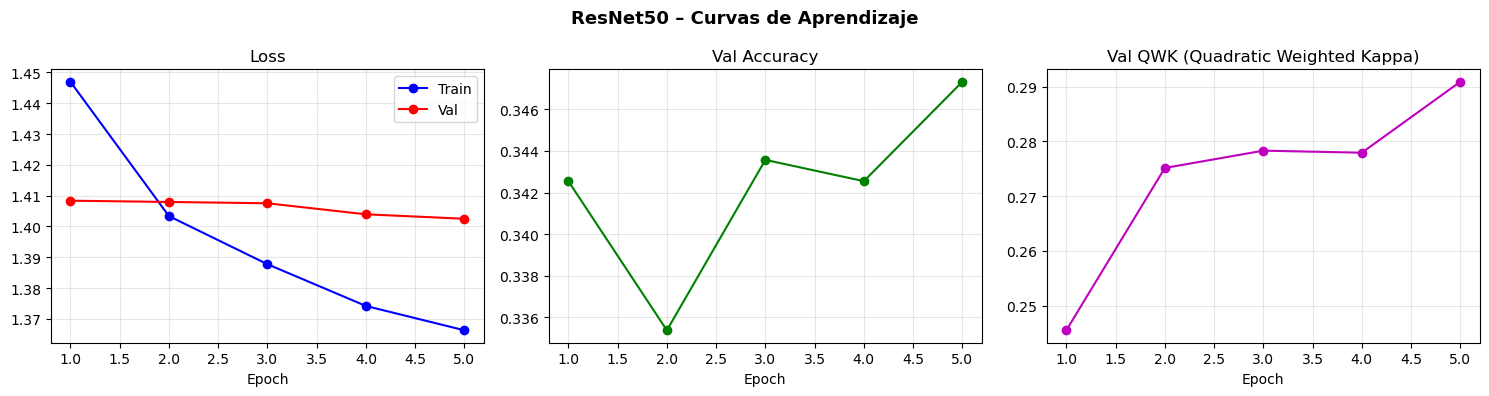

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], 'g-o')
axes[1].set_title('Val Accuracy')

axes[2].plot(epochs_range, history['val_kappa'], 'm-o')
axes[2].set_title('Val QWK (Quadratic Weighted Kappa)')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

plt.suptitle('ResNet50 – Curvas de Aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Alineación de Predicciones

ResNet opera en el orden del `val_loader` (por imagen disponible).  
Random Forest opera en el orden del `val_df` original.  
Alineamos ambas por `PetID`.

In [ ]:
# ── Probabilidades del ResNet ordenadas por PetID ──────────
resnet_proba_df = pd.DataFrame(
    resnet_val_proba,
    columns=[f'img_p{i}' for i in range(NUM_CLASSES)]
)
resnet_proba_df['PetID']      = val_pet_ids
resnet_proba_df['true_label'] = resnet_val_labels

# ── Probabilidades del RF ordenadas por PetID ─────────────
rf_proba_df = pd.DataFrame(
    rf_preds_proba,
    columns=[f'tab_p{i}' for i in range(NUM_CLASSES)]
)
rf_proba_df['PetID'] = val_df['PetID'].values

# ── Join por PetID ─────────────────────────────────────────
combined_df = resnet_proba_df.merge(rf_proba_df, on='PetID', how='inner')

print(f"Muestras en ResNet val:      {len(resnet_proba_df)}")
print(f"Muestras en RF val:          {len(rf_proba_df)}")
print(f"Muestras alineadas (inner):  {len(combined_df)}")
print(f"\nPrimeras filas del DataFrame combinado:")
combined_df.head(3)

Muestras en ResNet val:      2931
Muestras en RF val:          2999
Muestras alineadas (inner):  2931

Primeras filas del DataFrame combinado:


,img_p0,img_p1,img_p2,img_p3,img_p4,PetID,true_label,tab_p0,tab_p1,tab_p2,tab_p3,tab_p4
0,0.044064,0.434078,0.272480,0.165025,0.084353,015da9e87,0,0.390446,0.264188,0.178184,0.126513,0.040668
1,0.001789,0.087745,0.186643,0.383123,0.340701,022606901,0,0.037598,0.245984,0.318356,0.310287,0.087774
2,0.014994,0.175971,0.262920,0.267377,0.278738,02f89bdcb,0,0.034856,0.283291,0.328349,0.171286,0.182218


## 6. Meta-Modelo – Soft Voting

$$P_{meta}(c) = \alpha \cdot P_{RF}(c) + (1-\alpha) \cdot P_{ResNet}(c)$$

Probamos distintos valores de $\alpha$ para encontrar el mejor balance.

In [ ]:
img_cols = [f'img_p{i}' for i in range(NUM_CLASSES)]
tab_cols = [f'tab_p{i}' for i in range(NUM_CLASSES)]

img_proba = combined_df[img_cols].values    # shape: (N, 5)
tab_proba = combined_df[tab_cols].values    # shape: (N, 5)
true_labels = combined_df['true_label'].values

# ── Barrido de alpha ──────────────────────────────────────
#    alpha=1 → solo RF | alpha=0 → solo ResNet
alphas  = np.arange(0.0, 1.05, 0.05)
results = []

for alpha in alphas:
    blended_proba = alpha * tab_proba + (1 - alpha) * img_proba
    blended_preds = np.argmax(blended_proba, axis=1)
    kappa = cohen_kappa_score(true_labels, blended_preds, weights='quadratic')
    acc   = np.mean(blended_preds == true_labels)
    results.append({'alpha': alpha, 'qwk': kappa, 'accuracy': acc})

results_df = pd.DataFrame(results)
best_row   = results_df.loc[results_df['qwk'].idxmax()]
BEST_ALPHA = best_row['alpha']

print(f"\n{'Alpha':>8} | {'QWK':>8} | {'Accuracy':>10}")
print('-' * 35)
for _, row in results_df.iterrows():
    marker = " ◀ MEJOR" if row['alpha'] == BEST_ALPHA else ""
    print(f"{row['alpha']:>8.2f} | {row['qwk']:>8.4f} | {row['accuracy']:>10.4f}{marker}")


   Alpha |      QWK |   Accuracy
-----------------------------------
    0.00 |   0.2909 |     0.3473
    0.05 |   0.3031 |     0.3528
    0.10 |   0.3200 |     0.3627
    0.15 |   0.3301 |     0.3715
    0.20 |   0.3331 |     0.3739
    0.25 |   0.3481 |     0.3791
    0.30 |   0.3547 |     0.3859
    0.35 |   0.3590 |     0.3947
    0.40 |   0.3562 |     0.3934
    0.45 |   0.3587 |     0.3965
    0.50 |   0.3634 |     0.3965
    0.55 |   0.3660 |     0.4005
    0.60 |   0.3624 |     0.4036
    0.65 |   0.3635 |     0.4070
    0.70 |   0.3665 |     0.4087 ◀ MEJOR
    0.75 |   0.3560 |     0.4070
    0.80 |   0.3498 |     0.4063
    0.85 |   0.3475 |     0.4074
    0.90 |   0.3474 |     0.4070
    0.95 |   0.3414 |     0.4067
    1.00 |   0.3389 |     0.4084


### 6.1 Curva QWK vs Alpha

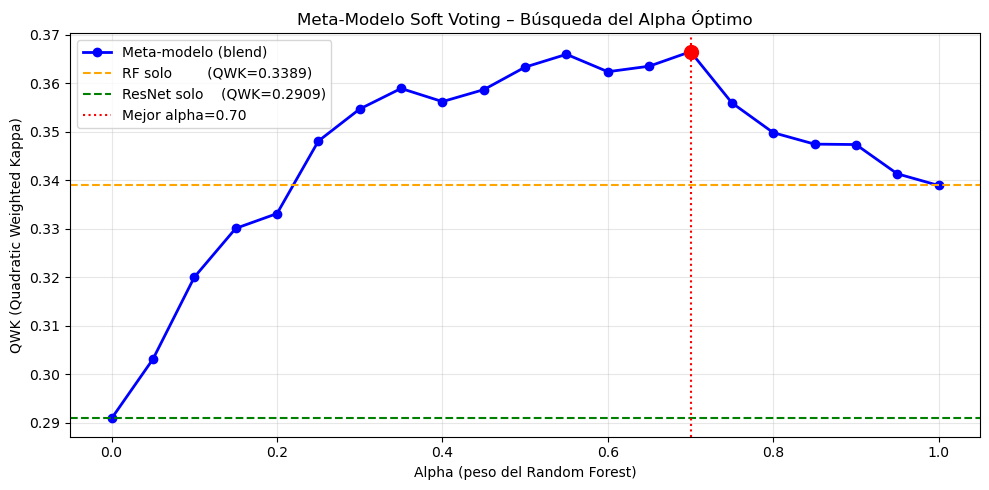


📊 Resumen Final:
   Random Forest solo:  QWK = 0.3389
   ResNet50 solo:       QWK = 0.2909
   Meta-Modelo (α=0.70): QWK = 0.3665
   Mejora sobre el mejor base: +0.0276


In [ ]:
rf_only_qwk     = results_df.loc[results_df['alpha'] == 1.0, 'qwk'].values[0]
resnet_only_qwk = results_df.loc[results_df['alpha'] == 0.0, 'qwk'].values[0]

plt.figure(figsize=(10, 5))
plt.plot(results_df['alpha'], results_df['qwk'], 'b-o', linewidth=2, label='Meta-modelo (blend)')
plt.axhline(rf_only_qwk,     color='orange', linestyle='--', linewidth=1.5, label=f'RF solo        (QWK={rf_only_qwk:.4f})')
plt.axhline(resnet_only_qwk, color='green',  linestyle='--', linewidth=1.5, label=f'ResNet solo    (QWK={resnet_only_qwk:.4f})')
plt.axvline(BEST_ALPHA,      color='red',    linestyle=':',  linewidth=1.5, label=f'Mejor alpha={BEST_ALPHA:.2f}')
plt.scatter([BEST_ALPHA], [best_row['qwk']], color='red', zorder=5, s=100)

plt.xlabel('Alpha (peso del Random Forest)')
plt.ylabel('QWK (Quadratic Weighted Kappa)')
plt.title('Meta-Modelo Soft Voting – Búsqueda del Alpha Óptimo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Resumen Final:")
print(f"   Random Forest solo:  QWK = {rf_only_qwk:.4f}")
print(f"   ResNet50 solo:       QWK = {resnet_only_qwk:.4f}")
print(f"   Meta-Modelo (α={BEST_ALPHA:.2f}): QWK = {best_row['qwk']:.4f}")
improvement = best_row['qwk'] - max(rf_only_qwk, resnet_only_qwk)
print(f"   Mejora sobre el mejor base: +{improvement:.4f}")

## 7. Evaluación Final del Meta-Modelo

In [ ]:
# Predicciones finales con el mejor alpha
final_proba = BEST_ALPHA * tab_proba + (1 - BEST_ALPHA) * img_proba
final_preds = np.argmax(final_proba, axis=1)

final_qwk = cohen_kappa_score(true_labels, final_preds, weights='quadratic')
final_acc  = np.mean(final_preds == true_labels)

print(f"Meta-Modelo Final (alpha={BEST_ALPHA:.2f})")
print(f"  QWK:      {final_qwk:.4f}")
print(f"  Accuracy: {final_acc:.4f}")
print()
print(classification_report(
    true_labels, final_preds,
    target_names=['Muy Rápido (0)', 'Rápido (1)', 'Normal (2)', 'Lento (3)', 'Muy Lento (4)']
))

Meta-Modelo Final (alpha=0.70)
  QWK:      0.3665
  Accuracy: 0.4087

                precision    recall  f1-score   support

Muy Rápido (0)       0.50      0.06      0.11        79
    Rápido (1)       0.36      0.39      0.37       611
    Normal (2)       0.35      0.38      0.36       798
     Lento (3)       0.40      0.22      0.28       641
 Muy Lento (4)       0.50      0.63      0.56       802

      accuracy                           0.41      2931
     macro avg       0.42      0.34      0.34      2931
  weighted avg       0.41      0.41      0.39      2931



### 7.1 Matrices de Confusión Comparativas

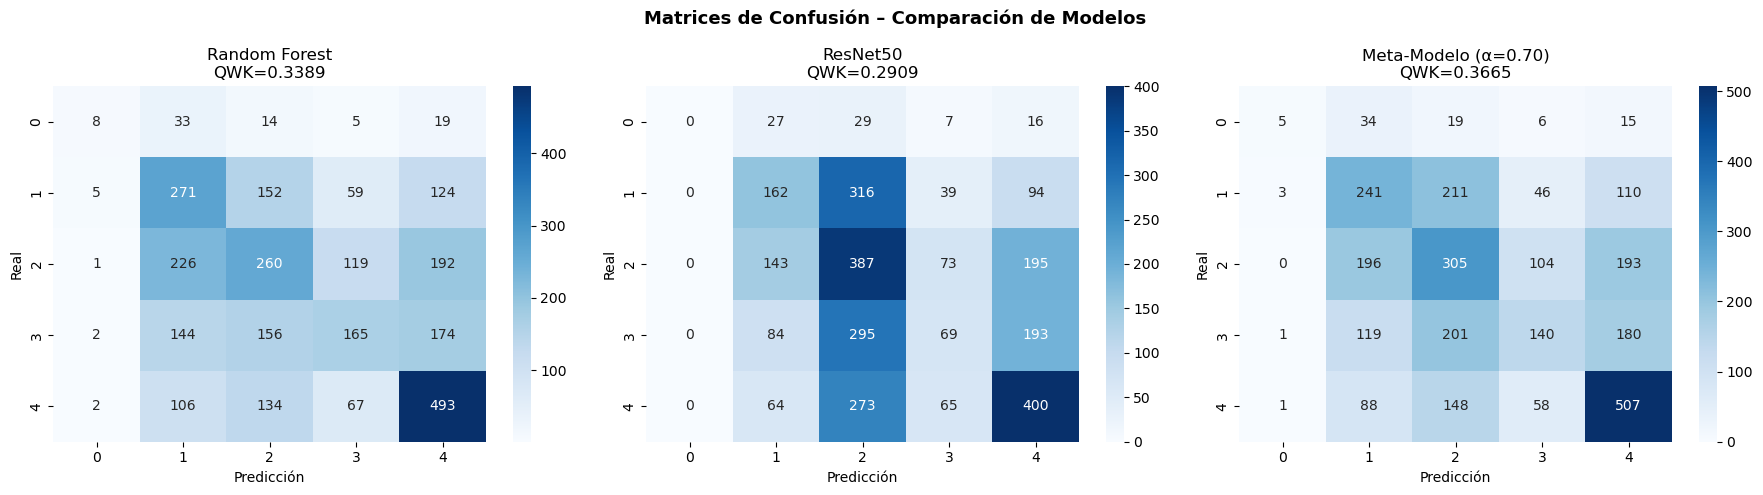

In [ ]:
rf_preds_aligned = np.argmax(tab_proba, axis=1)
rn_preds_aligned = np.argmax(img_proba, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (rf_preds_aligned, f'Random Forest\nQWK={rf_only_qwk:.4f}'),
    (rn_preds_aligned, f'ResNet50\nQWK={resnet_only_qwk:.4f}'),
    (final_preds,       f'Meta-Modelo (α={BEST_ALPHA:.2f})\nQWK={final_qwk:.4f}'),
]

for ax, (preds, title) in zip(axes, configs):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(title)

plt.suptitle('Matrices de Confusión – Comparación de Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Función de Inferencia (Producción)

Esta función recibe un `PetID` y devuelve la predicción final del meta-modelo.

In [ ]:
import torch.nn.functional as F
from PIL import Image


def predict_single_pet(
    pet_id: str,
    tabular_row: pd.Series,
    rf_model,
    resnet_model,
    train_columns: list,
    images_dir: str,
    alpha: float = BEST_ALPHA,
    device=DEVICE
):
    """
    Predice AdoptionSpeed para una mascota individual.

    Parámetros
    ----------
    pet_id        : ID de la mascota
    tabular_row   : fila del dataframe con sus características
    rf_model      : RandomForest entrenado
    resnet_model  : ResNet50 entrenado
    train_columns : columnas del X de entrenamiento (para alinear)
    images_dir    : carpeta raíz de las imágenes
    alpha         : peso del RF en el blend (1=solo RF, 0=solo ResNet)
    """
    # ── Predicción tabular ──────────────────────────────────
    single_df = pd.DataFrame([tabular_row])
    single_df = feature_engineering(single_df)
    cols_drop = ['AdoptionSpeed', 'Name', 'RescuerID', 'Description', 'PetID']
    X_single  = single_df.drop(columns=cols_drop, errors='ignore').fillna(-999)
    X_single  = pd.get_dummies(X_single, drop_first=True)
    X_single  = X_single.reindex(columns=train_columns, fill_value=0)
    tab_proba = rf_model.predict_proba(X_single)[0]   # (5,)

    # ── Predicción imagen ───────────────────────────────────
    img_path = os.path.join(images_dir, f'{pet_id}-1.jpg')
    if not os.path.exists(img_path):
        print(f"⚠️ Imagen no encontrada para {pet_id}. Usando solo RF.")
        img_proba = tab_proba  # fallback
    else:
        img = Image.open(img_path).convert('RGB')
        tensor = val_transforms(img).unsqueeze(0).to(device)
        resnet_model.eval()
        with torch.no_grad():
            logits = resnet_model(tensor)
        img_proba = F.softmax(logits, dim=1).cpu().numpy()[0]  # (5,)

    # ── Blend ───────────────────────────────────────────────
    blended  = alpha * tab_proba + (1 - alpha) * img_proba
    pred_cls = int(np.argmax(blended))

    return {
        'PetID':           pet_id,
        'AdoptionSpeed':   pred_cls,
        'proba_meta':      blended.tolist(),
        'proba_rf':        tab_proba.tolist(),
        'proba_resnet':    img_proba.tolist(),
        'confidence':      float(blended[pred_cls])
    }


# ── Ejemplo de uso ──────────────────────────────────────────
sample_row = val_df.iloc[0]
result = predict_single_pet(
    pet_id       = sample_row['PetID'],
    tabular_row  = sample_row,
    rf_model     = rf_model,
    resnet_model = resnet50,
    train_columns= X_train_tab.columns.tolist(),
    images_dir   = PATH_TO_IMAGES_DIR
)

print("\n🐾 Ejemplo de predicción:")
for k, v in result.items():
    print(f"  {k}: {v}")
print(f"  Etiqueta real: {sample_row['AdoptionSpeed']}")


🐾 Ejemplo de predicción:
  PetID: 8f20e24ef
  AdoptionSpeed: 3
  proba_meta: [0.02204387276225473, 0.2150794299810751, 0.3129510329001331, 0.3324147792987494, 0.11751089325342608]
  proba_rf: [0.02010032022074838, 0.15855407535598728, 0.3186890654383931, 0.3933538063413285, 0.10930273264354229]
  proba_resnet: [0.02657882682979107, 0.34697189927101135, 0.2995622754096985, 0.19022370874881744, 0.1366632580757141]
  confidence: 0.3324147792987494
  Etiqueta real: 4


## 9. Guardar Configuración del Meta-Modelo

In [ ]:
import json

meta_config = {
    'best_alpha':         float(BEST_ALPHA),
    'rf_qwk':             float(rf_only_qwk),
    'resnet_qwk':         float(resnet_only_qwk),
    'meta_qwk':           float(final_qwk),
    'meta_accuracy':      float(final_acc),
    'num_classes':        NUM_CLASSES,
    'image_size':         IMAGE_SIZE,
    'rf_train_columns':   X_train_tab.columns.tolist(),
    'imagenet_mean':      IMAGENET_MEAN,
    'imagenet_std':       IMAGENET_STD,
}

config_path = os.path.join(PATH_TO_WORK, 'meta_model_config.json')
with open(config_path, 'w') as f:
    json.dump(meta_config, f, indent=2)

print("✅ Archivos guardados en:", PATH_TO_WORK)
print(f"   • random_forest.joblib      → modelo Random Forest")
print(f"   • resnet50_best.pth         → pesos ResNet50")
print(f"   • meta_model_config.json    → configuración del meta-modelo")
print()
print("📊 Resultados Finales:")
print(f"   Random Forest:  QWK = {rf_only_qwk:.4f}")
print(f"   ResNet50:       QWK = {resnet_only_qwk:.4f}")
print(f"   Meta-Modelo:    QWK = {final_qwk:.4f}  ({'↑' if final_qwk > max(rf_only_qwk, resnet_only_qwk) else '↔'} mejor base)")

✅ Archivos guardados en: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\petfinder_work
   • random_forest.joblib      → modelo Random Forest
   • resnet50_best.pth         → pesos ResNet50
   • meta_model_config.json    → configuración del meta-modelo

📊 Resultados Finales:
   Random Forest:  QWK = 0.3389
   ResNet50:       QWK = 0.2909
   Meta-Modelo:    QWK = 0.3665  (↑ mejor base)


In [33]:
rf_only_qwk
resnet_only_qwk
final_qwk

0.3665494747860827